**Problem Statement: To predict total sales using product, pricing, and time-based features.**

- Import Require library

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

- Load the dataset - sales dataset
- using pd.read_csv

In [789]:
df=pd.read_csv('/content/sales.csv')

In [790]:
df

,Order_ID,Order_Date,Customer_ID,Region,City,Product_ID,Product_Category,Payment_Method,Discount,Product_Price,Quantity,Total_Before_Discount,Discount_Amount,Total_Sales
0,1,01-01-2023 00:00,1102,South,Pune,141,Electronics,Card,0.21,4411.30,6.0,26467.80,5558.2380,20528.80
1,2,01-01-2023 01:00,1435,West,Mumbai,318,Clothing,NetBanking,0.11,4726.34,9.0,42537.06,4679.0766,37301.49
2,3,01-01-2023 02:00,1860,South,Delhi,156,Electronics,Card,0.04,387.23,1.0,387.23,15.4892,197.89
3,4,01-01-2023 03:00,1270,East,Pune,325,Clothing,UPI,0.26,3725.55,4.0,14902.20,3874.5720,10944.11
4,5,01-01-2023 04:00,1106,East,Delhi,295,Clothing,NetBanking,0.18,3659.87,2.0,7319.74,1317.5532,5898.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,28-07-2023 03:00,1289,South,Delhi,106,Electronics,UPI,0.16,3670.48,1.0,3670.48,587.2768,2617.98
4996,4997,28-07-2023 04:00,1294,West,Delhi,102,Home,NetBanking,0.14,446.79,9.0,4021.11,562.9554,3504.23
4997,4998,28-07-2023 05:00,1450,South,Bangalore,406,Sports,Cash,0.09,210.82,4.0,843.28,75.8952,660.92
4998,4999,28-07-2023 06:00,1903,East,Bangalore,342,Electronics,Cash,0.04,2374.56,1.0,2374.56,94.9824,2133.31


- check the count of rows and columns

In [791]:
df.shape

(5000, 14)

- Information of dataset

In [792]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Order_ID               5000 non-null   int64  
 1   Order_Date             5000 non-null   object 
 2   Customer_ID            5000 non-null   int64  
 3   Region                 5000 non-null   object 
 4   City                   5000 non-null   object 
 5   Product_ID             5000 non-null   int64  
 6   Product_Category       5000 non-null   object 
 7   Payment_Method         5000 non-null   object 
 8   Discount               4750 non-null   float64
 9   Product_Price          4750 non-null   float64
 10  Quantity               4750 non-null   float64
 11  Total_Before_Discount  5000 non-null   float64
 12  Discount_Amount        5000 non-null   float64
 13  Total_Sales            5000 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 547.0+ 

- gives Statistical summary/ description

In [793]:
df.describe()

,Order_ID,Customer_ID,Product_ID,Discount,Product_Price,Quantity,Total_Before_Discount,Discount_Amount,Total_Sales
count,5000.000000,5000.000000,5000.0000,4750.000000,4750.000000,4750.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,1505.701200,299.9660,0.153126,2574.717198,5.071789,12986.867778,1977.749297,11351.675216
std,1443.520003,290.836902,116.0098,0.086504,1402.779169,2.573269,10237.119384,2121.877034,10016.887126
min,1.000000,1000.000000,100.0000,0.000000,100.540000,1.000000,102.500000,0.000000,-331.900000
25%,1250.750000,1253.000000,200.0000,0.080000,1365.967500,3.000000,4358.147500,432.816450,3765.990000
50%,2500.500000,1510.000000,301.5000,0.150000,2579.290000,5.000000,10266.015000,1210.035750,8813.840000
75%,3750.250000,1761.000000,401.0000,0.230000,3766.975000,7.000000,19351.475000,2865.261300,16677.532500
max,5000.000000,1999.000000,499.0000,0.300000,4998.030000,9.000000,44928.810000,13291.776000,124116.480000


- display the first few rows

In [794]:
df.head()

,Order_ID,Order_Date,Customer_ID,Region,City,Product_ID,Product_Category,Payment_Method,Discount,Product_Price,Quantity,Total_Before_Discount,Discount_Amount,Total_Sales
0,1,01-01-2023 00:00,1102,South,Pune,141,Electronics,Card,0.21,4411.30,6.0,26467.80,5558.2380,20528.80
1,2,01-01-2023 01:00,1435,West,Mumbai,318,Clothing,NetBanking,0.11,4726.34,9.0,42537.06,4679.0766,37301.49
2,3,01-01-2023 02:00,1860,South,Delhi,156,Electronics,Card,0.04,387.23,1.0,387.23,15.4892,197.89
3,4,01-01-2023 03:00,1270,East,Pune,325,Clothing,UPI,0.26,3725.55,4.0,14902.20,3874.5720,10944.11
4,5,01-01-2023 04:00,1106,East,Delhi,295,Clothing,NetBanking,0.18,3659.87,2.0,7319.74,1317.5532,5898.62


- display the last few rows

In [795]:
df.tail()

,Order_ID,Order_Date,Customer_ID,Region,City,Product_ID,Product_Category,Payment_Method,Discount,Product_Price,Quantity,Total_Before_Discount,Discount_Amount,Total_Sales
4995,4996,28-07-2023 03:00,1289,South,Delhi,106,Electronics,UPI,0.16,3670.48,1.0,3670.48,587.2768,2617.98
4996,4997,28-07-2023 04:00,1294,West,Delhi,102,Home,NetBanking,0.14,446.79,9.0,4021.11,562.9554,3504.23
4997,4998,28-07-2023 05:00,1450,South,Bangalore,406,Sports,Cash,0.09,210.82,4.0,843.28,75.8952,660.92
4998,4999,28-07-2023 06:00,1903,East,Bangalore,342,Electronics,Cash,0.04,2374.56,1.0,2374.56,94.9824,2133.31
4999,5000,28-07-2023 07:00,1214,South,Bangalore,155,Clothing,Cash,0.22,3976.81,3.0,11930.43,2624.6946,9708.34


**EDA**

- check for null values

In [796]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Region,0
City,0
Product_ID,0
Product_Category,0
Payment_Method,0
Discount,250
Product_Price,250


- null values are detected and handled

In [797]:
df['Discount'] = df['Discount'].fillna(0)

In [798]:
df['Product_Price'] = df['Product_Price'].fillna(df['Product_Price'].median())

In [799]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

In [800]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Region,0
City,0
Product_ID,0
Product_Category,0
Payment_Method,0
Discount,0
Product_Price,0


- check for duplicates and if finds then droped
- so it doesnt having duplicates.

In [801]:
df.duplicated().sum()

np.int64(0)

- Split the dataset into categorical and numerical column

In [802]:
categorical_cols=df.select_dtypes(include='object').columns
numerical_cols=df.select_dtypes(exclude='object').columns

In [803]:
categorical_cols

Index(['Order_Date', 'Region', 'City', 'Product_Category', 'Payment_Method'], dtype='object')

In [804]:
numerical_cols

Index(['Order_ID', 'Customer_ID', 'Product_ID', 'Discount', 'Product_Price',
       'Quantity', 'Total_Before_Discount', 'Discount_Amount', 'Total_Sales'],
      dtype='object')

- checking the unknown values

In [805]:
#checking the unknown values
for i in categorical_cols:
  print(df[i].value_counts())

Order_Date
28-07-2023 07:00    1
01-01-2023 00:00    1
01-01-2023 01:00    1
01-01-2023 02:00    1
01-01-2023 03:00    1
                   ..
01-01-2023 12:00    1
01-01-2023 11:00    1
01-01-2023 10:00    1
01-01-2023 09:00    1
01-01-2023 08:00    1
Name: count, Length: 5000, dtype: int64
Region
East     1260
South    1255
North    1244
West     1241
Name: count, dtype: int64
City
Chennai      1026
Pune         1023
Mumbai       1018
Bangalore     975
Delhi         958
Name: count, dtype: int64
Product_Category
Clothing       1274
Home           1263
Sports         1234
Electronics    1229
Name: count, dtype: int64
Payment_Method
Card          1278
NetBanking    1261
Cash          1233
UPI           1228
Name: count, dtype: int64


- Detect and handle the outlier
 uisng IQR and z_score
 - outlier detected and removed

In [806]:
outlier={}

In [807]:
for col in numerical_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

  df_iqr = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

  outlier[col] = len(outliers)

  print("Original Shape: ", df.shape)
  print("New Shape: ", df_iqr.shape)
  print("--"*50)

Original Shape:  (5000, 14)
New Shape:  (5000, 14)
----------------------------------------------------------------------------------------------------
Original Shape:  (5000, 14)
New Shape:  (5000, 14)
----------------------------------------------------------------------------------------------------
Original Shape:  (5000, 14)
New Shape:  (5000, 14)
----------------------------------------------------------------------------------------------------
Original Shape:  (5000, 14)
New Shape:  (5000, 14)
----------------------------------------------------------------------------------------------------
Original Shape:  (5000, 14)
New Shape:  (5000, 14)
----------------------------------------------------------------------------------------------------
Original Shape:  (5000, 14)
New Shape:  (5000, 14)
----------------------------------------------------------------------------------------------------
Original Shape:  (5000, 14)
New Shape:  (4963, 14)
-------------------------------------

In [808]:
from scipy import stats

In [809]:
z_score = np.abs(stats.zscore(df[numerical_cols]))

In [810]:
categorical_cols

Index(['Order_Date', 'Region', 'City', 'Product_Category', 'Payment_Method'], dtype='object')

- count of outlier using z_score

In [811]:
outliers = (z_score > 3).any(axis = 1) | (z_score < -3).any(axis = 1)

print("Number of outliers using Z-score: ", len(df[outliers]))

Number of outliers using Z-score:  122


In [812]:
## Removal of outliers using Z-score

df_zscore = df[(z_score < 3).all(axis=1)]

print("Original shape: ", df.shape)
print("New shape: ", df_zscore.shape)

Original shape:  (5000, 14)
New shape:  (4878, 14)


-  Create a separate copy of df_zscore to avoid modifying the original data

In [813]:
df = df_zscore.copy()

In [814]:
# df = df.drop(['Total_Before_Discount', 'Discount_Amount'], axis=1)

- Univariate analysis:
- histogram for distribution of columns
- Discount: Data is highly concentrated near 0, meaning most transactions have little or no discount. Very few values are on the higher side.
- Product_Price: Most values are concentrated in the lower to mid price range, with fewer high-priced products.
- Quantity: Data is mostly concentrated at lower quantities, showing customers usually buy fewer items.
- Total_Sales: Majority of data lies in the lower sales range, with a few high-value transactions spread far from the rest.

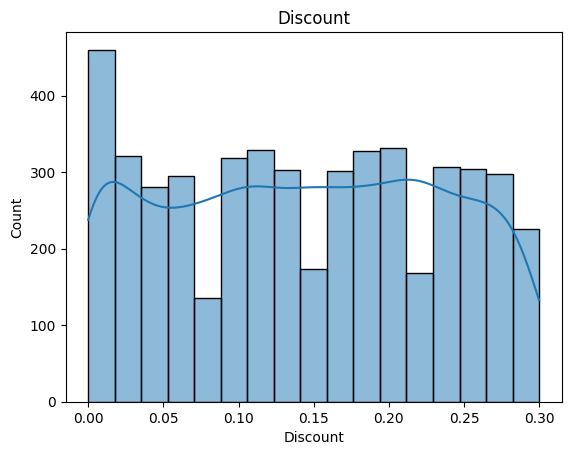

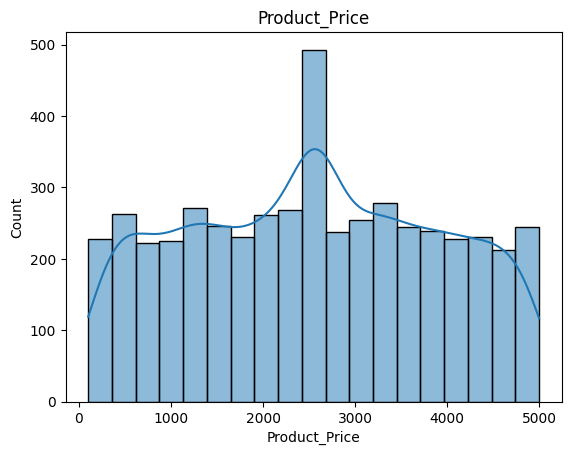

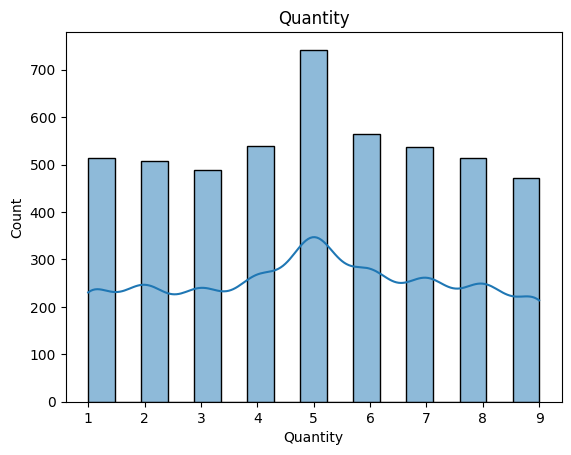

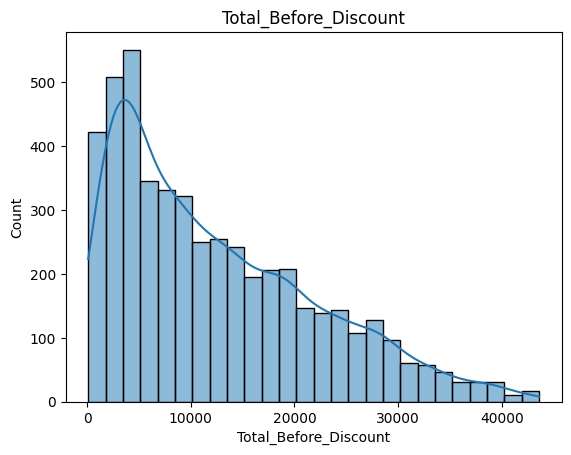

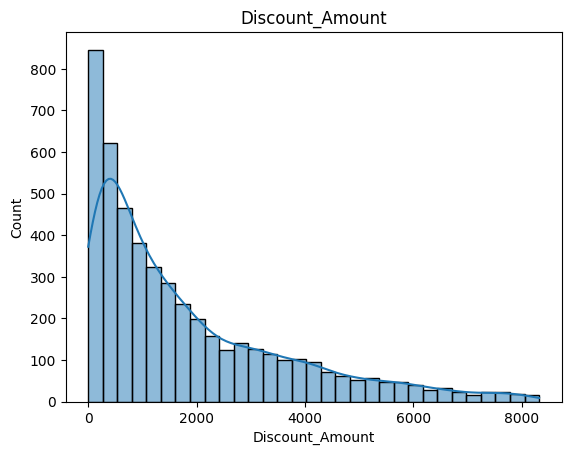

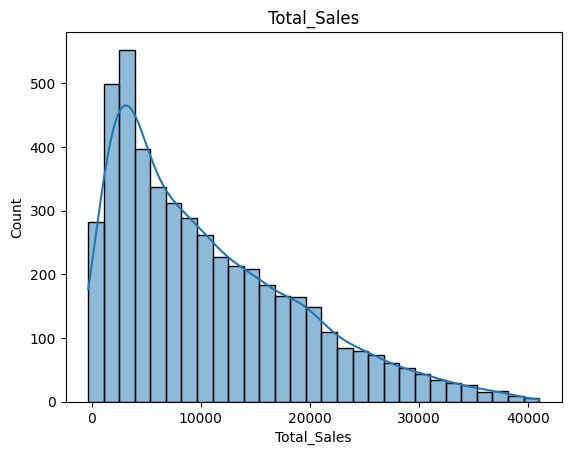

In [815]:
num_cols = ['Discount','Product_Price','Quantity',
            'Total_Before_Discount','Discount_Amount','Total_Sales']

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

- count of the values of quantity column

In [816]:
df['Quantity'].value_counts()

,count
Quantity,
5.0,742
6.0,565
4.0,540
7.0,537
1.0,513
8.0,513
2.0,508
3.0,488
9.0,472


- Product_Price vs Total_Sales:
Data is more concentrated in the lower to mid price range, and as price increases, sales also increase. Few points are spread at higher values.
- Quantity vs Total_Sales:
Data is highly concentrated at low quantity and low sales, with a clear upward trend showing that higher quantity leads to higher sales.

<Axes: xlabel='Product_Price', ylabel='Total_Sales'>

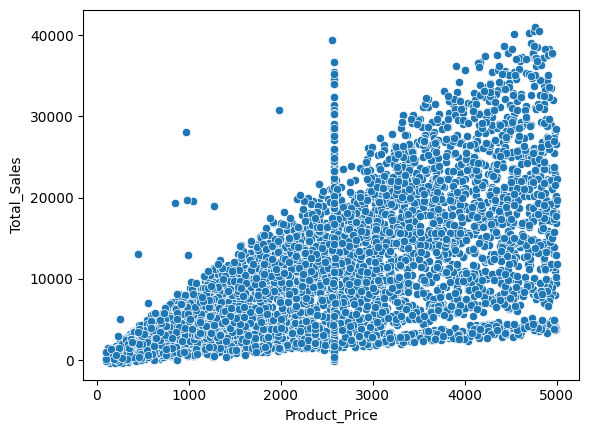

In [818]:
sns.scatterplot(x='Product_Price', y='Total_Sales', data=df)

<Axes: xlabel='Quantity', ylabel='Total_Sales'>

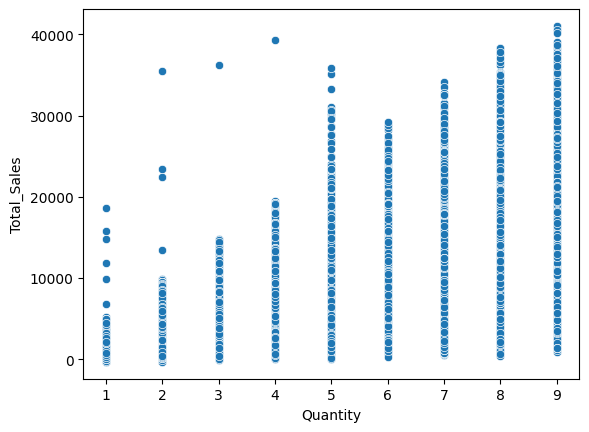

In [819]:
sns.scatterplot(x='Quantity', y='Total_Sales', data=df)

<Axes: xlabel='Region', ylabel='Total_Sales'>

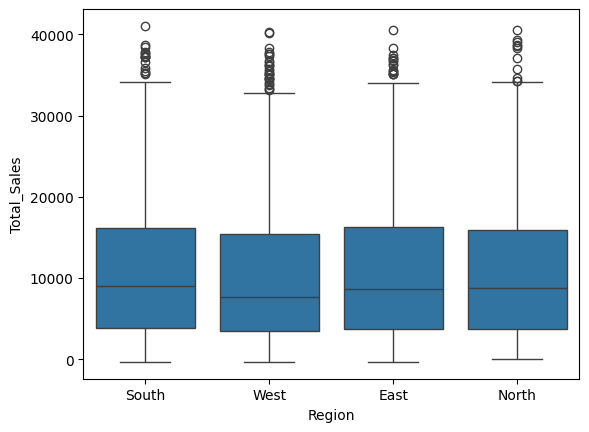

In [821]:
sns.boxplot(x='Region', y='Total_Sales', data=df)

- Total_Sales is highly correlated with Quantity and Product_Price.
- Moderate correlation is seen with Discount-related variables.
- Other variables show low or weak correlation.

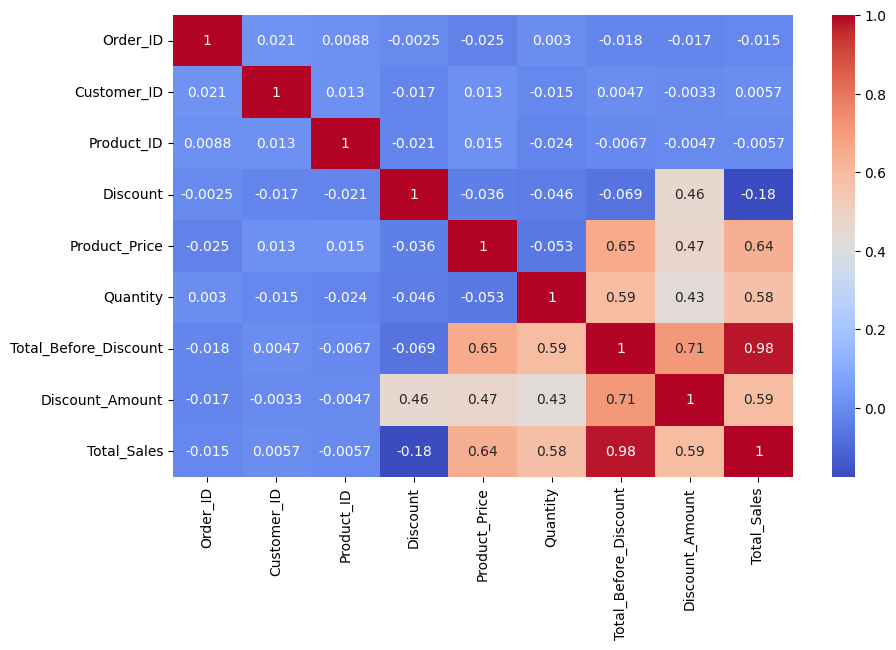

In [822]:
num_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [823]:
#  Drop City
# df = df.drop('City', axis=1)

In [824]:
categorical_cols

Index(['Order_Date', 'Region', 'City', 'Product_Category', 'Payment_Method'], dtype='object')

- The Order_Date column is converted into datetime format for easier analysis.
- New features (year, month, day) are extracted to capture time-based patterns.
- The original Order_Date column is dropped

In [825]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')

df['year'] = df['Order_Date'].dt.year
df['month'] = df['Order_Date'].dt.month
df['day'] = df['Order_Date'].dt.day

df.drop('Order_Date', axis=1, inplace=True)

In [826]:
df

,Order_ID,Customer_ID,Region,City,Product_ID,Product_Category,Payment_Method,Discount,Product_Price,Quantity,Total_Before_Discount,Discount_Amount,Total_Sales,year,month,day
0,1,1102,South,Pune,141,Electronics,Card,0.21,4411.30,6.0,26467.80,5558.2380,20528.80,2023,1,1
1,2,1435,West,Mumbai,318,Clothing,NetBanking,0.11,4726.34,9.0,42537.06,4679.0766,37301.49,2023,1,1
2,3,1860,South,Delhi,156,Electronics,Card,0.04,387.23,1.0,387.23,15.4892,197.89,2023,1,1
3,4,1270,East,Pune,325,Clothing,UPI,0.26,3725.55,4.0,14902.20,3874.5720,10944.11,2023,1,1
4,5,1106,East,Delhi,295,Clothing,NetBanking,0.18,3659.87,2.0,7319.74,1317.5532,5898.62,2023,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,1289,South,Delhi,106,Electronics,UPI,0.16,3670.48,1.0,3670.48,587.2768,2617.98,2023,7,28
4996,4997,1294,West,Delhi,102,Home,NetBanking,0.14,446.79,9.0,4021.11,562.9554,3504.23,2023,7,28
4997,4998,1450,South,Bangalore,406,Sports,Cash,0.09,210.82,4.0,843.28,75.8952,660.92,2023,7,28
4998,4999,1903,East,Bangalore,342,Electronics,Cash,0.04,2374.56,1.0,2374.56,94.9824,2133.31,2023,7,28


- Categorical columns (Region, City, Product_Category, Payment_Method) are converted into numerical format using one-hot encoding.
- drop_first=True is used to avoid multicollinearity by removing one category from each variable.
This transformation makes the data suitable for machine learning models.

In [827]:
df = pd.get_dummies(df, columns=[
    'Region',
    'City',
    'Product_Category',
    'Payment_Method'
], drop_first=True)

In [828]:
df

,Order_ID,Customer_ID,Product_ID,Discount,Product_Price,Quantity,Total_Before_Discount,Discount_Amount,Total_Sales,year,...,City_Chennai,City_Delhi,City_Mumbai,City_Pune,Product_Category_Electronics,Product_Category_Home,Product_Category_Sports,Payment_Method_Cash,Payment_Method_NetBanking,Payment_Method_UPI
0,1,1102,141,0.21,4411.30,6.0,26467.80,5558.2380,20528.80,2023,...,False,False,False,True,True,False,False,False,False,False
1,2,1435,318,0.11,4726.34,9.0,42537.06,4679.0766,37301.49,2023,...,False,False,True,False,False,False,False,False,True,False
2,3,1860,156,0.04,387.23,1.0,387.23,15.4892,197.89,2023,...,False,True,False,False,True,False,False,False,False,False
3,4,1270,325,0.26,3725.55,4.0,14902.20,3874.5720,10944.11,2023,...,False,False,False,True,False,False,False,False,False,True
4,5,1106,295,0.18,3659.87,2.0,7319.74,1317.5532,5898.62,2023,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,1289,106,0.16,3670.48,1.0,3670.48,587.2768,2617.98,2023,...,False,True,False,False,True,False,False,False,False,True
4996,4997,1294,102,0.14,446.79,9.0,4021.11,562.9554,3504.23,2023,...,False,True,False,False,False,True,False,False,True,False
4997,4998,1450,406,0.09,210.82,4.0,843.28,75.8952,660.92,2023,...,False,False,False,False,False,False,True,True,False,False
4998,4999,1903,342,0.04,2374.56,1.0,2374.56,94.9824,2133.31,2023,...,False,False,False,False,True,False,False,True,False,False


- The columns Total_Before_Discount and Discount_Amount are removed.
- These variables are highly related to Total_Sales, which may cause redundancy.

In [829]:
df = df.drop([
    'Total_Before_Discount',
    'Discount_Amount'
], axis=1)

In [830]:
# df = df.drop('Order_ID', axis=1)

- The dataset is divided into input features (X) and target variable (y).
- Total_Sales is taken as the target variable, while all other columns are used as input features.

In [831]:
X = df.drop('Total_Sales', axis=1) #input
y = df['Total_Sales'] #output

- The data is split into training and testing sets.
- 80% data is used for training and 20% for testing.
- random_state=42 ensures reproducibility of results.

In [832]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

- It ensures all features are on the same scale, improving model performance.

In [844]:
# from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Only transform test data
X_test_scaled = scaler.transform(X_test)



- The Linear Regression model is initialized and stored in the variable lr.
- This step prepares the model for training on the dataset.

In [851]:
# Model initialization

from sklearn.linear_model import LinearRegression
lr = LinearRegression()  ## storing the model in an alias name

- The Linear Regression model is trained using X_train and y_train.

In [845]:
#  Model training (MOST IMPORTANT)

lr.fit(X_train, y_train) ## Takes the X_train, y_train. Applied OLS method to get the best fit line

LinearRegression()

- Intercept represents the base value of Total_Sales when all features are zero.


In [846]:
##  Extract model parameters

lr.intercept_

np.float64(-8535.300735690902)

- Coefficients show the impact of each feature on Total_Sales.

In [847]:
lr.coef_

array([ 2.36234378e-01,  5.94154852e-02, -3.69726383e-01, -1.17505869e+04,
        4.18004048e+00,  2.08751051e+03,  8.64019967e-12, -1.76169982e+02,
       -5.20237871e-01,  1.06638631e+01,  2.28890074e+02,  1.05382953e+02,
        1.24433156e+02,  3.96024544e+02, -2.18377406e+01,  5.42001721e+02,
       -2.55533416e+02, -2.09609718e+02,  1.98388942e+02, -2.94987364e+02,
       -1.52955313e+02, -3.64267839e+02])

-Model Evaluation
- MAE (~2828.76): Average prediction error is moderate.
- MSE (~15137486): Indicates presence of some large errors.
- R² (~0.80): Model explains about 80% of the variance, showing good performance.

In [848]:
##  Model evalauation

y_pred = lr.predict(X_test)



In [849]:
from sklearn import metrics
print("MAE: ", metrics.mean_absolute_error(y_test, y_pred))
print("MSE: ", metrics.mean_squared_error(y_test, y_pred))
print("R2 score: ", metrics.r2_score(y_test, y_pred))


MAE:  2828.7621206284175
MSE:  15137486.296461876
R2 score:  0.8000785037948717


- A sample input is created and modified with new values.
- The model predicts Total_Sales ≈ 701.12 for the given input.
- This shows how the trained model can be used for future predictions.

In [850]:
new_data = X_train.iloc[[0]].copy()

In [840]:
new_data['Discount'] = 10
new_data['Product_Price'] = 500
new_data['Quantity'] = 2
new_data['year'] = 2023
new_data['month'] = 5
new_data['day'] = 12

In [841]:
prediction = model.predict(new_data)
print("Predicted Total Sales:", prediction[0])

Predicted Total Sales: 701.1187999999999


- The graph shows actual and predicted Total_Sales values together.
- Most predicted values follow the same pattern as actual values.
- Some deviations can be seen where predictions are slightly higher or lower.

- The scatter plot shows the relationship between actual sales (X-axis) and predicted sales (Y-axis).
- Most of the data points follow an upward trend, which means the model is able to capture the overall pattern in the data.

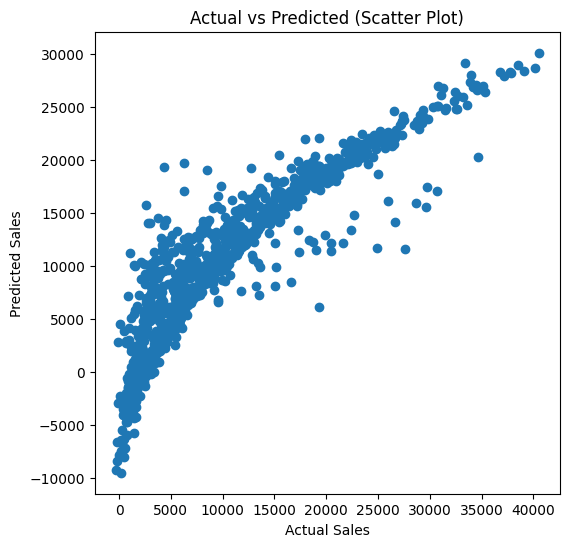

In [854]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted (Scatter Plot)")

plt.show()